# Problem 1 - Real GDP across US states

**Question 1.1 - downloading and computing the data**


1.1.1) Downloading the data from FRED

In [ ]:
from data_loader import load_state_data

# a. FRED API key
api_key = 'Indsæt API koden til FRED her'

# b. downloading real GDP and population for all the states by importing our data loading function.
df_gdp, df_pop = load_state_data(api_key)

# c. Controlling that the data has been correctly loaded from the
print('Real GDP — millions of chained 2017 $ (first 5 rows):')
display(df_gdp.head())
print('Population — thousands of persons (first 5 rows):')
display(df_pop.head())

Real GDP — millions of chained 2017 $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0000,41071.0000,180293.9000,87180.3000,1441226.4000,189445.6000,205965.2000,51267.0000,603988.6000,351183.9000,...,27116.2000,226832.8000,860046.9000,86283.5000,21372.2000,319992.6000,281522.2000,60364.6000,222978.5000,24257.7000
1998,160396.4000,40263.7000,197492.1000,89905.3000,1538612.3000,206449.1000,212255.0000,56487.0000,634032.3000,377705.9000,...,28772.1000,240963.4000,920059.6000,91312.7000,22266.5000,338931.5000,299817.0000,61725.7000,232087.1000,24804.7000
1999,166531.8000,39783.1000,214293.9000,94756.9000,1655438.5000,221040.8000,218860.0000,60866.2000,664152.0000,404465.2000,...,30038.3000,248457.5000,957247.2000,95206.8000,23561.7000,356391.8000,322721.6000,63691.7000,242026.0000,25866.8000
2000,168695.3000,38428.1000,224729.3000,95509.8000,1784320.6000,238739.3000,233874.2000,63388.8000,693837.3000,417713.5000,...,32124.9000,251030.2000,989904.9000,98648.5000,24844.6000,372914.1000,325857.6000,63364.6000,248572.0000,26614.2000
2001,168448.3000,40014.4000,230885.6000,95528.7000,1784567.7000,242650.1000,236338.1000,65724.8000,714638.0000,422731.6000,...,32396.9000,250311.4000,1020517.0000,100244.3000,25681.8000,386444.7000,317860.6000,63599.8000,252941.8000,28338.1000


Population — thousands of persons (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0000,NaN,124.0000,1314.0000,1490.0000,543.0000,910.0000,185.0000,530.0000,2220.0000,...,403.0000,2023.0000,3055.0000,277.0000,344.0000,1858.0000,523.0000,959.0000,2072.0000,93.0000
1901,1907.0000,NaN,131.0000,1341.0000,1550.0000,581.0000,931.0000,187.0000,544.0000,2263.0000,...,418.0000,2041.0000,3132.0000,284.0000,347.0000,1887.0000,583.0000,972.0000,2109.0000,100.0000
1902,1935.0000,NaN,138.0000,1360.0000,1623.0000,621.0000,952.0000,188.0000,565.0000,2305.0000,...,431.0000,2060.0000,3210.0000,292.0000,349.0000,1894.0000,651.0000,1000.0000,2141.0000,105.0000
1903,1957.0000,NaN,144.0000,1384.0000,1702.0000,652.0000,972.0000,190.0000,587.0000,2346.0000,...,437.0000,2082.0000,3291.0000,299.0000,350.0000,1890.0000,719.0000,1037.0000,2171.0000,108.0000
1904,1978.0000,NaN,151.0000,1419.0000,1792.0000,659.0000,987.0000,192.0000,599.0000,2387.0000,...,452.0000,2086.0000,3374.0000,308.0000,353.0000,1889.0000,782.0000,1064.0000,2202.0000,111.0000


1.1.2) Merging the data


After examining the data we expect the merged series to only contain data from 1997 to 2025 as these are the only years where both series contain data.

In [90]:
from states import STATES

# a. We use an inner join on the year, such that we only keep observations in both series.
years = df_gdp.index.intersection(df_pop.index)
gdp = df_gdp.loc[years]
pop = df_pop.loc[years]

# b. We now drop missing observation in either series
complete = gdp.notna().all(axis=0) & pop.notna().all(axis=0)
gdp = gdp.loc[:, complete]
pop = pop.loc[:, complete]

# c. Printing what is kept and dropped
dropped = [s for s in STATES if s not in gdp.columns]
print(f'years:  {gdp.shape[0]}  ({years.min()}–{years.max()})')
print(f'states: {gdp.shape[1]}')
print(f'dropped states: {dropped if dropped else "none"}')

years:  29  (1997–2025)
states: 50
dropped states: none


1.1.3) Computing real gdp. pr person

In [91]:
# we multiply with 1000 such that we get the number in dollars pr. person
y = gdp / pop * 1_000   

# a. displaying our computations
print('Real GDP per person, $ (first 5 rows):')
display(y.tail())

Real GDP per person, $ (first 5 rows):


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
2021,46326.4184,70466.5187,54503.2033,45467.1377,80482.1693,69880.2002,75054.7222,74821.6649,53701.1273,59644.7821,...,62496.0532,57656.3437,64434.9080,63262.7159,51888.6407,65333.7463,80849.2577,42684.3069,56926.4389,64145.3123
2022,47243.0246,68845.4718,56145.8820,45504.5876,80439.1946,72193.8273,77195.6669,79499.6271,55587.0532,61309.0293,...,60778.5683,58818.1345,65580.8443,64187.8083,53914.6776,66731.8586,82577.6041,43714.1876,57910.8701,64789.2021
2023,48519.1438,73754.1754,57385.9113,46245.8174,81773.3559,74459.9678,77780.7742,79287.7605,57105.7629,61412.4663,...,62384.8393,59873.3907,69582.9784,65614.7016,54806.5374,68627.8821,85598.5880,45402.9749,58530.8118,68146.9420
2024,49511.2680,75957.7591,59150.7570,47605.3267,84007.3056,74950.0459,77878.3703,81276.6695,58122.7764,62249.0139,...,62255.8272,60706.4590,70946.4938,66886.0226,56299.6407,69584.3097,88576.6928,46801.1805,59488.3508,67801.6164
2025,50191.3312,77974.1479,59779.1290,48362.8918,86110.4864,76198.3288,79436.9304,82344.3892,59406.9699,62853.0602,...,62576.8105,61428.8355,71813.8176,68039.9638,57251.9285,70263.6691,89678.6785,47091.6068,60206.9185,67924.0700


1.1.4) Highest and lowest values

In [92]:
# a. Extracting the first and last years
tfirst, tlast = y.index.min(), y.index.max()

# b. Looping through the first and last periods for all states and printing the results
for t in (tfirst, tlast):
    row = y.loc[t]   

    print(f'{t}:')
    print(f'  highest: {row.idxmax()} with {row.max():,.0f} $ pr. person')
    print(f'  lowest:  {row.idxmin()} with {row.min():,.0f} $ pr. person')
    print(f'  ratio:   {row.max()/row.min():.2f}')
    print(f'  average across all states: {row.mean():,.0f} $ pr. person')
    print()

1997:
  highest: DE with 69,749 $ pr. person
  lowest:  ID with 32,063 $ pr. person
  ratio:   2.18
  average across all states: 44,593 $ pr. person

2025:
  highest: NY with 94,702 $ pr. person
  lowest:  MS with 42,434 $ pr. person
  ratio:   2.23
  average across all states: 64,674 $ pr. person



1.1.5) Plotting descriptive statistics for the states we found in 1.1.4

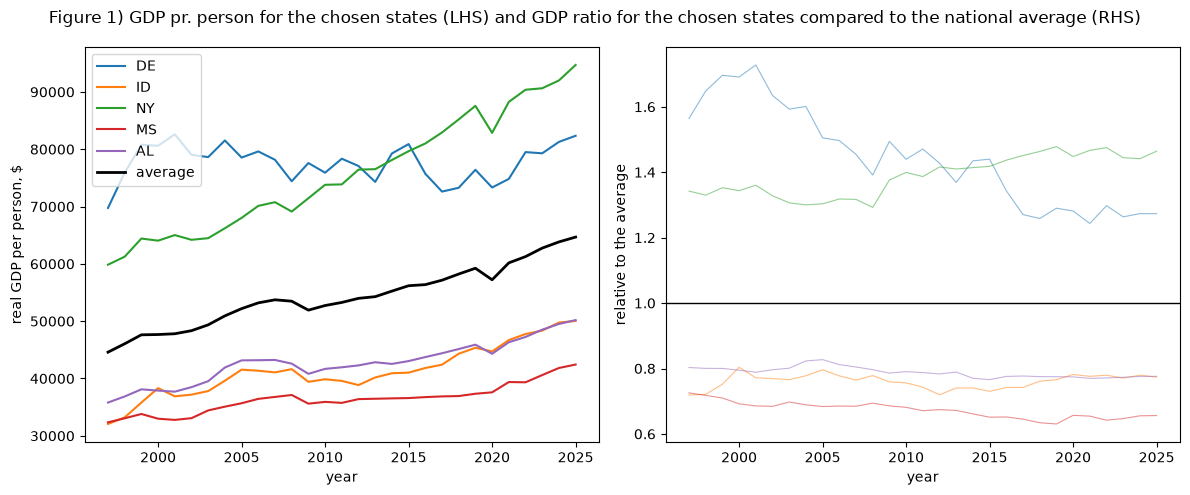

In [93]:
import matplotlib.pyplot as plt

# a. Specifying the states 
some_states = ['DE','ID','NY','MS','AL'] 

# b. yearly averages
avg = y.mean(axis=1)        

# c. GDP pr person divided by the yearly average across all states in that year
ratio = y.divide(avg, axis=0)                            

# d. specifying the plot
fig = plt.figure(figsize=(12,5))

# i. averages for the specified states
ax1 = fig.add_subplot(1,2,1)
for state in some_states:
    ax1.plot(y.index, y[state], label=state)
ax1.plot(y.index, avg, color='black', lw=2, label='average')
ax1.set_xlabel('year')
ax1.set_ylabel('real GDP per person, $')
ax1.legend(loc='upper left')

# ii: the specified states relative to the average across all states
ax2 = fig.add_subplot(1,2,2)
for state in some_states:
    ax2.plot(ratio.index, ratio[state], lw=0.8, alpha=0.5)
ax2.axhline(1, color='black', lw=1)                    
ax2.set_xlabel('year')
ax2.set_ylabel('relative to the average')

fig.suptitle("Figure 1) GDP pr. person for the chosen states (LHS) and GDP ratio for the chosen states compared to the national average (RHS)")
fig.tight_layout()

We have read this question as the second plot to only account for the handful of states as in the first plot. Here we chose the four that we found in question 1.1.4. plus Alabama. 

From panel 1, we see that all states display a clear growth in GDP pr. person. New York and Idaho has the highest growth, whereas Misssisipi and Alabama display growthpatterns that are more in line with the national average. The levels are however different. Delaware has the most fluctuating growth of them all. 

Looking at panel 2, we see how the states perform relative to the average across states, where a value of 1 represents the average. Delaware is clearly above the average throughout the period, but its relative position decreases over time. New York moves further above the average and ends at around 1.45. Idaho and Alabama remain stable at around 0.8 of the average, while Mississippi stays at the lowest level and falls slightly further behind. Overall, the figure shows that the relative development differs quite a lot across the chosen states.



**Question 1.2) Standard deviation and plotting**

1997: 0.1833
2025:  0.1786
highest: 2012 with 0.1909
lowest:  2005 with 0.1683


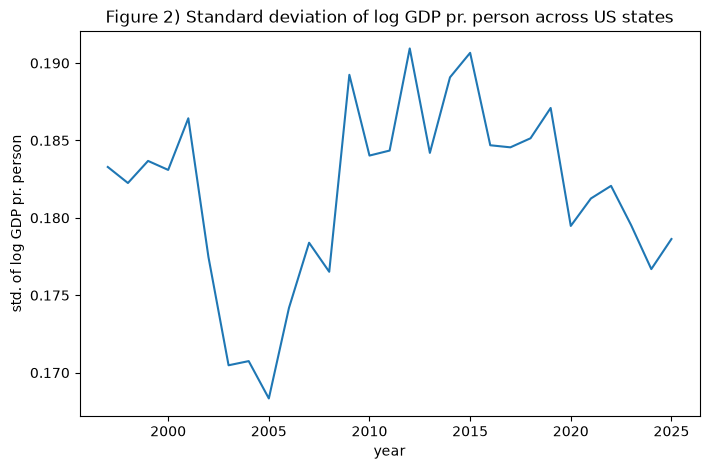

In [94]:
import numpy as np

# a. Standard deviation across states of log gdp pr. person for each year
logy = np.log(y)              
sigma = logy.std(axis=1)      

# b. plotting the standard deviation of log(GDP)
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(sigma.index, sigma)
ax.set_xlabel('year')
ax.set_ylabel('std. of log GDP pr. person')
ax.set_title('Figure 2) Standard deviation of log GDP pr. person across US states')

# b. printing our results 
print(f'{tfirst}: {sigma.loc[tfirst]:.4f}')
print(f'{tlast}:  {sigma.loc[tlast]:.4f}')
print(f'highest: {sigma.idxmax()} with {sigma.max():.4f}')
print(f'lowest:  {sigma.idxmin()} with {sigma.min():.4f}')

The overall pattern is fluctuating with no clear trend. It starts at 0.1833 in 1997 and falls to its lowest value of 0.1683 in 2005. After 2005, the standard deviation increases again and reaches its highest value of 0.1909 in 2012. From around 2019 onwards, it generally decreases, ending at 0.1786 in 2025. Interestingly we see that the smallest standard deviation in GDP pr person is in 2005, which is just before the financial crisis. Similar, the largest dispersion is in 2012 which is a few years after the financial crisis. 

**Question 1.3) Growth, speed of convergence and the half life**

level intercept (a) = 0.118
slope parameter (b) = -0.010
correlation between log(GDP) in the first year and the growth average in that year = -0.389
Speed of convergence (lambda) = 0.011
Half life (h) = 60.492


Text(0.5, 1.0, 'Figure 3) Correlation between annual growth and log(GDP) pr. person')

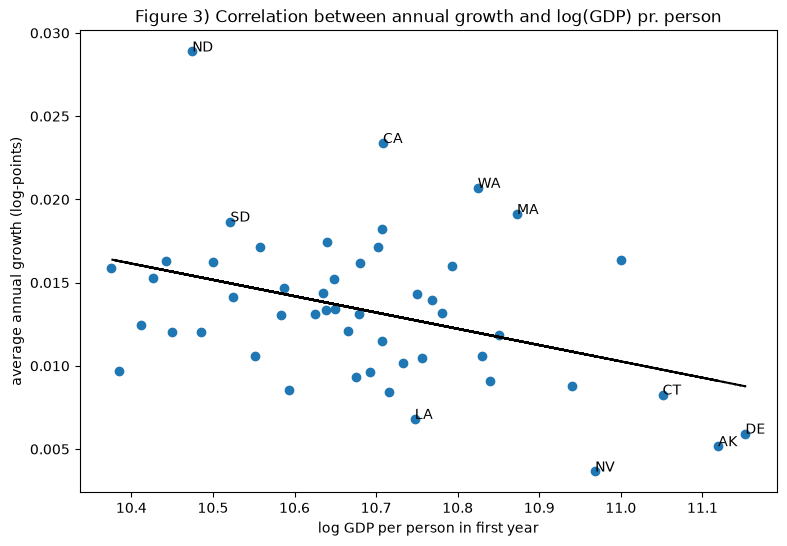

In [95]:
# a. taking the log and constructing the numerator as T
logy = np.log(y)
T = tlast - tfirst

# b. calculating the average growth rate                      
g = (logy.loc[tlast] - logy.loc[tfirst]) / T   

# c. fitting the regression line using polyfit. 
x = logy.loc[tfirst]  
b, a = np.polyfit(x, g, 1) # b specifies the slope parameter, whereas a specifies the level intercept of the OLS regression

# d. correlation between log(GDP) in the first year and the growth rate in that year
corr = x.corr(g)

# e. deriving the speed of convergence and the half life
lamb = -np.log(1 + b*T) / T
h = np.log(2) / lamb

# f. printing our computations
print(f'level intercept (a) = {a:.3f}')
print(f'slope parameter (b) = {b:.3f}')
print(f'correlation between log(GDP) in the first year and the growth average in that year = {corr:.3f}')
print(f'Speed of convergence (lambda) = {lamb:.3f}')
print(f'Half life (h) = {h:.3f}')

# g. Scatterplot with the regression line
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)
ax.scatter(x, g)
ax.plot(x, (a + b*x), color='black', ls='--')

# h. labeling the 5 highest and 5 lowest growth states in the scatterplot
for state in list(g.sort_values().index[:5]) + list(g.sort_values().index[-5:]):
    ax.annotate(state, (x[state], g[state]))

ax.set_xlabel('log GDP per person in first year')
ax.set_ylabel('average annual growth (log-points)')

plt.title("Figure 3) Correlation between annual growth and log(GDP) pr. person")


The fitted line has an intercept of a = 0.1181 and a slope of b = -0.0098. We see that the slope is negative, which indicates convergence in growth rates, since the states with the highest initial values of log(GDP) tend to have lower growth rates. This is also clear from the negative correlation of -0.389 between the average annual growth and the initial level of log(GDP)

From the slope we obtain a speed of convergence of lambda = 0.0115, corresponding to approx 1.15% per year, and a half-life of around 60.5 years. Hence from the estimated relationship, it would take roughly 60 years for half of an initial difference in GDP per person between two states to disappear. This in total indicates convergence between the states.


**Question 1.4) Regions and convergence**

South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64
           first   last  change
Midwest   0.9680 1.0060  0.0370
Northeast 1.0870 1.0950  0.0080
South     0.9510 0.9050 -0.0460
West      1.0290 1.0450  0.0170
Biggest change is in South with a change of -0.046


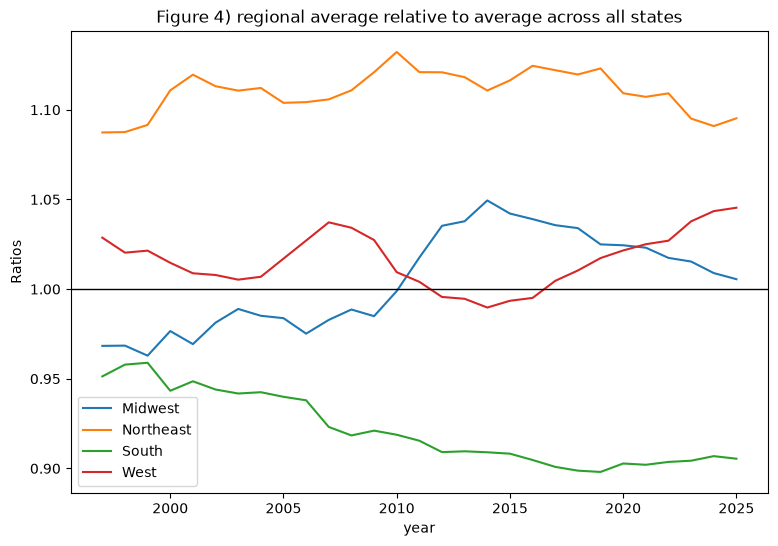

In [96]:
from states import REGION
import pandas as pd


# a. Calculating ratio between GDP pr. persion relative to the GDP pr. person across all states
avg = y.mean(axis=1)
ratio = y.divide(avg, axis=0)

# b. we now group the states into their respective regions and calculate the average ratio for each region
region_ratio = ratio.T.groupby(REGION).mean().T     

# c. Counting the number of states in each region
counts = pd.Series(REGION).loc[y.columns].value_counts()
print(counts)

# d. plotting the four regional series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)
for region in region_ratio.columns:
    ax.plot(region_ratio.index, region_ratio[region], label=region)
ax.axhline(1, color='black', lw=1)              # the all-state average
ax.set_xlabel('year')
ax.set_ylabel('Ratios')
ax.legend()
plt.title("Figure 4) regional average relative to average across all states")

# e. the summary statistics for the first and last year including the change
summary = pd.DataFrame({'first': region_ratio.loc[tfirst],
                        'last':  region_ratio.loc[tlast]})
summary['change'] = summary['last'] - summary['first']
print(summary.round(3))

# f. calculating the biggest changes.
big_change = summary['change'].abs().idxmax()
print(f'Biggest change is in {big_change} with a change of {summary.loc[big_change, "change"]:+.3f}')

There are 16 states in the South, 13 in the West, 12 in the Midwest and 9 in the Northeast. Figure 4 shows each regions average GDP pr. person relative to the average across all states. We see that the Northeast is clearly above the average throughout the period at around 1.09–1.13. The West is also above the average and increases over time, while the Midwest and the South both lie below the national average. The Southern region has the largest change over with a decrease of -0.046 over the period. Since the change is negative it indicates that the Southern region becomes poorer relative to the national average in terms of GDP pr. person.

# Problem 2 - The solow model with a time varying savings rate

**Question 2.1) Calibrating the Solow model**

2.1.1) Computing the steady state

In [97]:
# a. importing packages
import copy
import numpy as np
import matplotlib.pyplot as plt

# b. importing the model provided with the exam description 
from SolowModel import SolowModelClass

# c. setting up the model with the calibration baked into the template
model = SolowModelClass()
par = model.par

# d. defining long-run savings rate (s)
s = par.s_bar

# e. deriving the SS values using the class specified in the solow.py file
k_ss, y_ss, c_ss = model.steady_state(s)

# f. We now compute the SS numerically using the rootfinder and brentq method
k_root = model.solve_steady_state(s)

# g. Sanity checking whether the numerically solves k* and analytically derived k* are approximately equal 
assert np.isclose(k_ss, k_root), 'formula and root-finder disagree on k*'

# h. Printing the results
print(f'k* (formula)     = {k_ss:.4f}')
print(f'y* (formula)     = {y_ss:.4f}')
print(f'c* (formula)     = {c_ss:.4f}')
print(f'k* (root-finder) = {k_root:.4f}')
print(f'absolute difference betwen numerical and analytical k*    = {abs(k_ss-k_root):.2e}')


k* (formula)     = 0.7607
y* (formula)     = 0.9129
c* (formula)     = 0.6847
k* (root-finder) = 0.7607
absolute difference betwen numerical and analytical k*    = 0.00e+00


2.1.2) Simulating the model

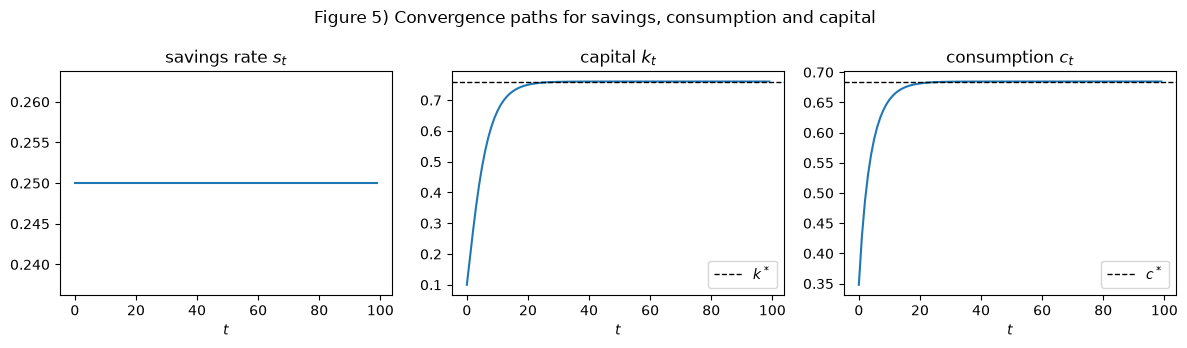

c_0     = 0.3481
c_(T-1) = 0.6847
k_(T-1) = 0.7607


In [98]:
# a. We now simulate the baseline model with a constant savings rate and capital starting from 0.10.
baseline = copy.deepcopy(model.simulate(s))   
t = np.arange(par.T)

# b. plotting savings, capital and consumption in three different panels.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, baseline.s)
axes[0].set_title('savings rate $s_t$'); axes[0].set_xlabel('$t$')

axes[1].plot(t, baseline.k)
axes[1].axhline(k_ss, ls='--', color='k', lw=1, label='$k^*$')
axes[1].set_title('capital $k_t$'); axes[1].set_xlabel('$t$'); axes[1].legend()

axes[2].plot(t, baseline.c)
axes[2].axhline(c_ss, ls='--', color='k', lw=1, label='$c^*$')
axes[2].set_title('consumption $c_t$'); axes[2].set_xlabel('$t$'); axes[2].legend()

fig.suptitle("Figure 5) Convergence paths for savings, consumption and capital")
fig.tight_layout()
plt.show()

# c. printing the values
print(f'c_0     = {baseline.c[0]:.4f}')
print(f'c_(T-1) = {baseline.c[-1]:.4f}')
print(f'k_(T-1) = {baseline.k[-1]:.4f}')

From the plots we see a rapid convergence within the 20 years. In period 99 both consumption and capital takes on their SS values.

2.1.3) Sanity checks

In [99]:
# a. We use the hint and construct the sanity check with the starting point of k*
sim_ss = model.simulate(s, k0=k_ss)                
assert np.allclose(sim_ss.k, k_ss), 'starting at k* should stay at k*'

# b. We now control that with zero savings, capital will depreciate towards zero
sim_zero = model.simulate(0.0)
k_decay = (1 - par.delta)**t * par.k0             
assert np.allclose(sim_zero.k, k_decay), 's=0 should give geometric decay'

print('both assert tests passed (thumbs up)')

both assert tests passed (thumbs up)


**Question 2.2) different values of initial savings and convergence speed**

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


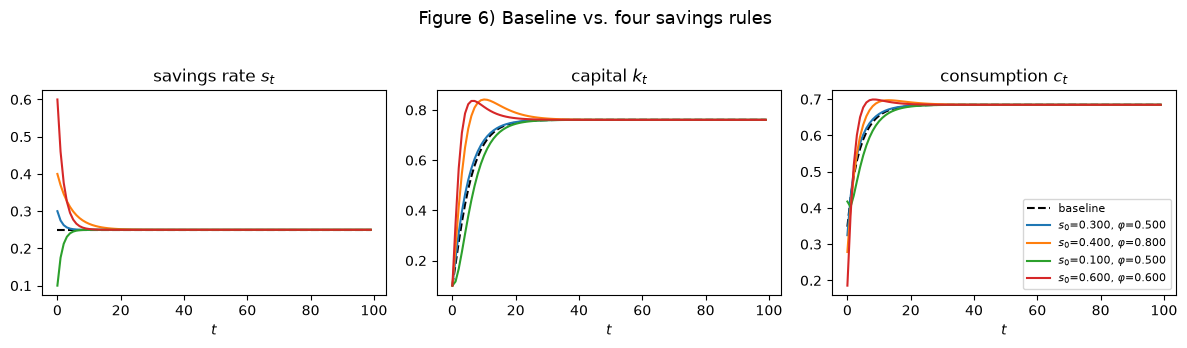

In [100]:
# Autoloading the changes in the .py when calling from the notebook. 
%load_ext autoreload
%autoreload 2


# a. the combinations of savings and convergence
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

# b. simulating the baseline model and the four different combination of savings and convergence
results = {}
results['baseline'] = copy.deepcopy(model.simulate(par.s_bar))
for (s0, phi) in combos:
    label = f'$s_0$={s0:.3f}, $\\varphi$={phi:.3f}'
    results[label] = copy.deepcopy(model.simulate(model.s_path(s0, phi)))

# c. ploting all the different paths
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for label, sim in results.items():
    style = 'k--' if label == 'baseline' else '-'   # baseline dashed black
    axes[0].plot(t, sim.s, style, label=label)
    axes[1].plot(t, sim.k, style, label=label)
    axes[2].plot(t, sim.c, style, label=label)

axes[0].set_title('savings rate $s_t$'); axes[0].set_xlabel('$t$')
axes[1].set_title('capital $k_t$');      axes[1].set_xlabel('$t$')
axes[2].set_title('consumption $c_t$');  axes[2].set_xlabel('$t$')
axes[2].legend(fontsize=8)               

fig.suptitle('Figure 6) Baseline vs. four savings rules', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

From the left panel we see that all the saving rates converge towards the equilibrium savings rate s̅ regardless of the speed of convergence and the starting point. The lower the φ value and the closer the starting point is to s̅ the quicker is the convergence speed. 

From the middle and right panels, we see that all paths eventually converge towards the same steady-state levels of capital and consumption. When s_0 is above s̅, more output is initially invested, which causes capital to accumulate faster and can make capital temporarily exceed its steady-state level. At the same time, consumption is initially lower because a larger share of output is saved. As the savings rate falls back towards s̅, the economy consumes a larger share of the higher output generated by the accumulated capital, causing consumption to temporarily exceed the baseline.

When s_0 is below s̅  the opposite happens. Consumption is initially higher because less output is saved, but capital accumulates more slowly. As the savings rate returns to s̅, the differences gradually disappear. Overall, s_0 mainly determines the initial direction and size of the deviation from the baseline, while φ determines how persistent this deviation is.

**Question 2.3) implementing welfare in the model**

In [101]:
# a. welfare of the baseline with constant savings
base = model.simulate(par.s_bar)
W_base = model.welfare(base.c)

# b. welfare and difference for each combination of savings and convergence
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

print(f'{"rule":<22}{"W":>12}{"W - W_base":>14}')
print(f'{"baseline":<22}{W_base:>12.6f}{0.0:>+14.6f}')
for (s0, phi) in combos:
    W = model.evaluate(s0, phi)
    print(f'{"s0="+f"{s0:.2f}, phi="+f"{phi:.2f}":<22}{W:>12.6f}{W-W_base:>+14.6f}')

rule                             W    W - W_base
baseline                 -3.994388     +0.000000
s0=0.30, phi=0.50        -3.985706     +0.008682
s0=0.40, phi=0.80        -4.091413     -0.097025
s0=0.10, phi=0.50        -4.146018     -0.151630
s0=0.60, phi=0.60        -4.340653     -0.346265


As the welfare is defined as the discounted value of log consumption, it makes sense that the savings rule with s0 = 0.30 yields the highest welfare as this path is very stable and always above the baseline scenario. One might think that the red curve with the highest savings would lead to the largest welfare as consumption spikes under this rule. However in the initial periods, consumption is below the baseline scenario leading to a lower welfare. Hence the plot alone is not sufficent to determine the welfare maximizing rule. One could also expect the welfare to be greatest with the lowest savings rate since the consumption in the short term is the greatest, but in the future periods the consumption is lower, which dominates the utility relative to the baseline. 

**Question 2.4) Computing welfare**

2.4.1) Using grid to find the optimal savings rate and convergence speed

grid best: s_0=0.3091, phi=0.2303, W=-3.984314


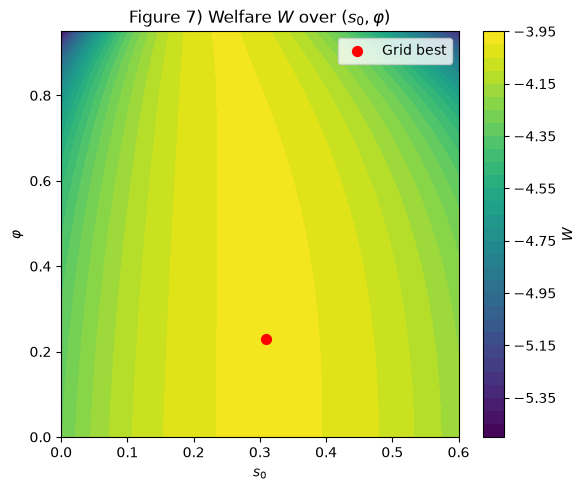

In [102]:
# a. Making the grids for the two parameters
Ns0, Nphi = 100, 100 # number of grid points
s0_grid  = np.linspace(0.0, 0.60, Ns0)
phi_grid = np.linspace(0.0, 0.95, Nphi)
S0, PHI = np.meshgrid(s0_grid, phi_grid, indexing='ij') # two 2D arrays listing every (s0,phi) combination

# b. We now use a double loop to compute welfare at every grid point
W_grid = np.empty((Ns0, Nphi))
for i in range(Ns0):
    for j in range(Nphi):
        W_grid[i,j] = model.evaluate(S0[i,j], PHI[i,j])

# c. Solving for the optimal point on the grid
i, j = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_g, phi_g, W_g = S0[i,j], PHI[i,j], W_grid[i,j]
print(f'grid best: s_0={s0_g:.4f}, phi={phi_g:.4f}, W={W_g:.6f}')

# d. Illustrating the welfare surface
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(S0, PHI, W_grid, levels=30, cmap='viridis')
fig.colorbar(cs, ax=ax, label='$W$')
ax.scatter(s0_g, phi_g, color='red', s=50, label='Grid best')
ax.set_xlabel('$s_0$')
ax.set_ylabel('$\\varphi$')
ax.set_title('Figure 7) Welfare $W$ over $(s_0,\\varphi)$')
ax.legend()
plt.tight_layout()
plt.show()

2.4.2) Numerical optimization with the best initial grid point 

In [103]:
from scipy import optimize

# a. We now solve for the numerically smallets welfare
neg_W = lambda x: -model.evaluate(x[0], x[1])

# b. our initial guess is the best grid point from before
x0 = np.array([s0_g, phi_g])
path = [x0.copy()]

# c. Minimize with L-BFGS-B over the box bounds from the question
res = optimize.minimize(
    neg_W,
    x0,
    method='L-BFGS-B',
    bounds=((0.0, 0.60), (0.0, 0.95)),
    callback=lambda xk: path.append(xk.copy())
)

# d. Extracting the results 
s0_opt, phi_opt = res.x
W_opt = -res.fun

# e. Comparing the optimizer with the grid in a small table
compare = pd.DataFrame(
    [
        {'method': 'Grid',      's0': s0_g,   'phi': phi_g,   'W': W_g,   'evaluations': Ns0*Nphi},
        {'method': 'Optimizer', 's0': s0_opt, 'phi': phi_opt, 'W': W_opt, 'evaluations': res.nfev},
    ]
)
display(compare.round({'s0': 6, 'phi': 6, 'W': 6}))
print(f'W improvement over grid: {W_opt - W_g:+.2e} when using the L-BFGS-B method for optimization')

,method,s0,phi,W,evaluations
0,Grid,0.3091,0.2303,-3.9843,10000
1,Optimizer,0.3115,0.2208,-3.9843,24


W improvement over grid: +1.41e-05 when using the L-BFGS-B method for optimization


We see that we get a small improvement in welfare, when using the optimizer instead of the grid search to find the highest level of welfare. The big improvement in iterations stems from the initial guess for the optimizer is the finial result from the grid search.

2.4.3) Plotting savings, capital and consumption under the new best rule

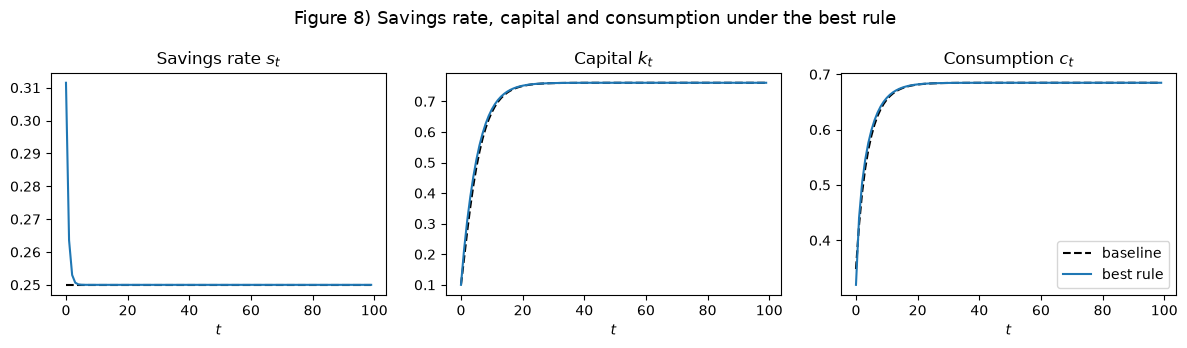

c0 (best rule) = 0.3196
c0 (baseline)  = 0.3481
first period where consumption from the new optimal rule is greater than baseline consumption: t = 1


In [104]:
# a. Simulating the best rule as computed in 2.4.2 and the baseline 
best = copy.deepcopy(model.simulate(model.s_path(s0_opt, phi_opt)))
base = copy.deepcopy(model.simulate(par.s_bar))
t = np.arange(par.T)

# b. Plotting s_t, k_t and c_t against the baseline
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for name, sim, style in [('baseline', base, 'k--'), ('best rule', best, '-')]:
    axes[0].plot(t, sim.s, style, label=name)
    axes[1].plot(t, sim.k, style, label=name)
    axes[2].plot(t, sim.c, style, label=name)

axes[0].set_title('Savings rate $s_t$')
axes[0].set_xlabel('$t$')
axes[1].set_title('Capital $k_t$')
axes[1].set_xlabel('$t$')
axes[2].set_title('Consumption $c_t$')
axes[2].set_xlabel('$t$')
axes[2].legend()
fig.suptitle('Figure 8) Savings rate, capital and consumption under the best rule', size=13)
plt.tight_layout()
plt.show()

# c. printing c0 and the first period where c_best exceeds c_base
crossover = np.where(best.c > base.c)[0][0]
print(f'c0 (best rule) = {best.c[0]:.4f}')
print(f'c0 (baseline)  = {base.c[0]:.4f}')
print(f'first period where consumption from the new optimal rule is greater than baseline consumption: t = {crossover}')

This showcases that the savings rate is initially larger, which results in an initially smaller consumption. However, the savings rate quickly converges towards the long run equilibrium, which results in the consumption under the best rule to be greater than the baseline already in period 1. This results in the total discounted welfare of the best rule to be greater than that of the baseline.

**Question 2.5) including a long run value for savings**


In [105]:
# a. The new savings rule: s_t = s_inf + (s0 - s_inf)*phi**t
def s_path3(s0, phi, s_inf):
    """ savings rule with a free long-run level s_inf """
    t = np.arange(par.T)
    return s_inf + (s0 - s_inf)*phi**t

# b. Welfare under the new rule
def evaluate3(s0, phi, s_inf):
    """ welfare W of the rule (s0, phi, s_inf) """
    return model.welfare(model.simulate(s_path3(s0, phi, s_inf)).c)

# c. The optimal is the numerically smallest welfare. Hence the minus for the minimizer
neg_W = lambda x: -evaluate3(x[0], x[1], x[2])

# d. The initial vaules are taken from the question above
x0 = np.array([s0_opt, phi_opt, par.s_bar])
path = [x0.copy()]

# e. Minimizing with the L-BFGS-B method
res3 = optimize.minimize(
    neg_W,
    x0,
    method='L-BFGS-B',
    bounds=((0.0, 0.99), (0.0, 0.95), (0.0, 0.99)),
    callback=lambda xk: path.append(xk.copy())
)

# f. Extracting the results 
s0_3, phi_3, sinf_3 = res3.x
W_3 = -res3.fun

# g. printing and comparing with Question 4
print(f'The optimal rule with the 3 parameters: s0={s0_3:.4f}, phi={phi_3:.6f}, s_inf={sinf_3:.6f}')
print(f'Welfare under the new optimal rule = {W_3:.6f}')
print(f'Welfare from question 4 = {W_opt:.6f}')
print(f'Welfare improvement = {W_3 - W_opt:+.6f}')

The optimal rule with the 3 parameters: s0=0.3139, phi=0.670773, s_inf=0.198944
Welfare under the new optimal rule = -3.966965
Welfare from question 4 = -3.984300
Welfare improvement = +0.017335


2.5.2) Comparision of optimal capital under the new rule and capital from question 1

In [106]:
# a. Simulate the new best optimal rule
sim_new_optimal = model.simulate(s_path3(s0_3, phi_3, sinf_3))

# b. optimal captial from question 1
k_star_sinf, _, _ = model.steady_state(sinf_3) #we ignore the total production y and consumption c

print(f'k_(T-1) under the new optimal rule = {sim_new_optimal .k[-1]:.4f}')
print(f'k* from question 1 = {k_ss:.4f}')

k_(T-1) under the new optimal rule = 0.5400
k* from question 1 = 0.7607


This showcases that the savings rate is initially larger, which results in an initially smaller consumption. However, the savings rate quickly converges towards the long run equilibrium, which results in the consumption under the best rule to be greater than the baseline already in period 1. This results in the total discounted welfare of the best rule to be greater than that of the baseline.

**Question 2.6) Different functional form for savings**

2.6.1) and 2.6.2) Different functional form


We choose a generalized exponential savings rule because it gives the savings rate more flexibility in how it adjusts over time, while still ensuring convergence to a constant long-run level as required by the question. Compared with the previous specification, the additional shape parameter allows the transition towards the long-run savings rate to be either faster or slower at different points in time. This gives the model more freedom to balance the short-run cost of lower consumption against the long-run benefit of higher capital accumulation, and may therefore lead to a higher level of welfare.

In [107]:
# a. the alternative savings rule: a generalized (stretched) exponential decay
def s_path_alt(s0, rho, p, s_inf):
    """ exponential savings rule s_t = s_inf + (s0-s_inf)*exp(-rho*t**p)

        Starts at s0, settles at the constant long-run level s_inf and reduces to
        the rule from queestion 5 when p = 1.

        Args:
            s0 (float): savings rate in period 0
            rho (float): decay speed towards s_inf
            p (float): shape parameter of the transition 
            s_inf (float): long-run savings rate

        Returns:
            (ndarray): savings rate for each of the par.T periods
    """

    # i. time index 
    t = np.arange(par.T)

    # ii. exponential decay from s0 down to s_inf
    return s_inf + (s0 - s_inf)*np.exp(-rho * t**p)


# b. welfare at a given parameter
def evaluate_alt(s0, rho, p, s_inf):
    """ welfare W of the exponential rule

        Args:
            s0, rho, p, s_inf (float): the four rule parameters (see s_path_alt)

        Returns:
            (float): welfare W of the resulting consumption path
    """

    # i. simulating the savings path
    return model.welfare(model.simulate(s_path_alt(s0, rho, p, s_inf)).c)


# c. minimize minus welfare, so that actual welfare is maximized
neg_W = lambda x: -evaluate_alt(*x)

# d. bounding the transition
bounds = ((0.0, 0.99), (0.0, 10.0), (0.1, 5.0), (0.0, 0.99))

# e. different initial guesses
starts = [
    [0.3139, -np.log(0.670774), 1.0, 0.1989],  # = the geometric Q5 optimum
    [0.40, 0.20, 1.5, 0.20],
    [0.60, 1.00, 0.7, 0.15],
]

# f. run L-BFGS-B from each start and keeping the best
best_alt = None
for x0 in starts:
    res = optimize.minimize(neg_W, x0, method='L-BFGS-B', bounds=bounds)
    if best_alt is None or res.fun < best_alt.fun:  # keep the best welfare so far
        best_alt = res

# g. extracting the results 
s0_a, rho_a, p_a, sinf_a = best_alt.x
W_alt = -best_alt.fun

# h. printing the best rule
print(f'Values for the best alternative rule: s0={s0_a:.4f}, rho={rho_a:.4f}, p={p_a:.4f}, s_inf={sinf_a:.4f}')
print(f'Welfare in our speficied rule = {W_alt:.6f}')

Values for the best alternative rule: s0=0.3130, rho=0.3710, p=1.0908, s_inf=0.2001
Welfare in our speficied rule = -3.966951


2.6.3) Summarizing the results in a table

In [108]:
# a. collecting the welfare values for all the different savings rule
table = pd.DataFrame([
    {'rule': 'Question 4 rule', 'W': W_opt},  # from 2.4.2
    {'rule': 'Question 5 rule',     'W': W_3},     # from 2.5
    {'rule': 'Question 6 rule', 'W': W_alt},
])

# b. displaying the table
display(table.round(6))

,rule,W
0,Question 4 rule,-3.9843
1,Question 5 rule,-3.9670
2,Question 6 rule,-3.9670


Both question 5 and question 6 improve clearly on question 4, since freeing the long-run rate s_inf is what raises welfare the most. Question 6 gives the highest welfare, but only beats question 5 by about a very small number. This welfare also equals the ceiling from choosing the savings rate freely in every period, so we cannot meaningfully beat question 5, whose rule was already essentially optimal.

# Problem 3 - A portfolio with a risky and a safe asset

**Question 3.1) analyzing the model**


3.1.1) Comuputing the return on the portfolio

In [109]:
# a. importing package
import numpy as np
import matplotlib.pyplot as plt
from PortfolioModel import PortfolioModelClass

# b. The model with the baseline calibration of seed=2026, N=50_000, T=40
model = PortfolioModelClass()
par = model.par

# c. drawing epsilon for all portfolios and periods 
rng = np.random.default_rng(par.seed)
eps = rng.normal(size=(par.N, par.T))

# d. return on the risky asset
R = np.exp(par.mu + par.sigma*eps)

# e. Printing epsilon and R to control that the shape is of baseline (N,T)
print(f'eps shape = {eps.shape}, R shape = {R.shape}')


eps shape = (50000, 40), R shape = (50000, 40)


3.1.2) Mean and standard deviation of the return across all draws

In [110]:
# a. log returns 
logR = np.log(R)

# b. mean and standard deviation of log R across all draws compared with mu and sigma
print('log R_t across all draws:')
print(f'  mean = {logR.mean():.4f} compared with mu = {par.mu:.2f}')
print(f'  std  = {logR.std():.4f} compared with sigma = {par.sigma:.2f}')

# c. mean of the simuæated R compared with the theoretical mean of R 
print('\nR_t across all draws:')
print(f'  Simulated mean of R = {R.mean():.4f}')
print(f'  Theoretical mean of R = {np.exp(par.mu + 0.5*par.sigma**2):.4f}')


log R_t across all draws:
  mean = 0.0500 compared with mu = 0.05
  std  = 0.2000 compared with sigma = 0.20

R_t across all draws:
  Simulated mean of R = 1.0725
  Theoretical mean of R = 1.0725


We see that the mean and standard deviation of the log return from the simulated model yields the same values as the baseline parameters, when including 4 decimals. Furthermore we see that the mean of the portfolio return across all draws yields the exact same value as the theoretical benchmark given by the listed expression. 

3.1.3) Plotting the results

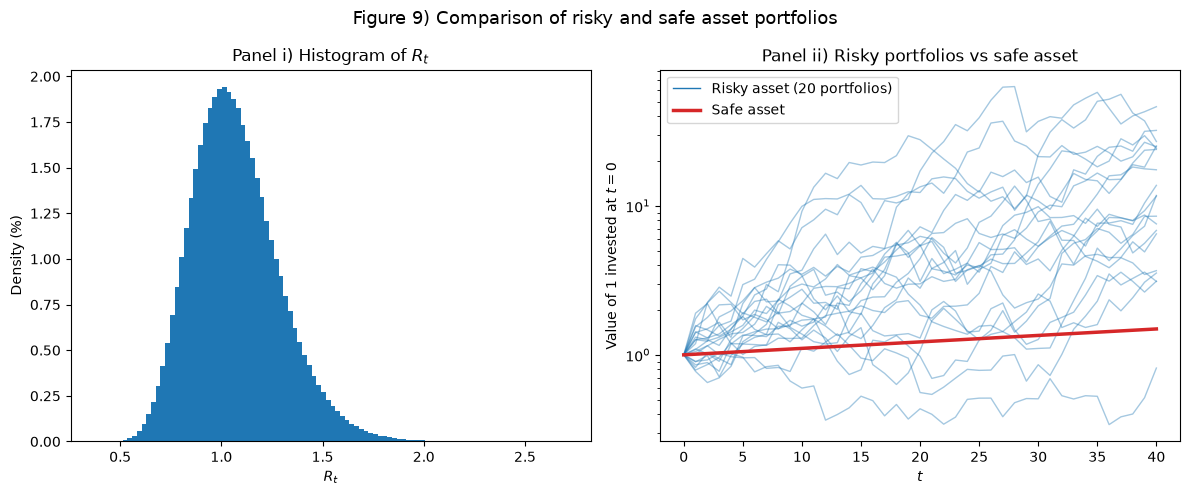

In [111]:
# a. We make the data for the second panel, where we invest everything (1) into the risky asset in period t=0 for 20 different portfolios going forward. 
Nshow = 20
t_grid = np.arange(par.T+1)

risky = np.ones((Nshow, par.T+1))          # start every path at 1 in t=0
risky[:,1:] = np.cumprod(R[:Nshow], axis=1) # The return of the risky asset
safe = np.exp(par.r * t_grid)               # The return of the safe asset. 

# b. figure with two panels
fig = plt.figure(figsize=(12,5))

# c. panel i: histogram of R_t over all draws
ax1 = fig.add_subplot(1,2,1)
ax1.hist(R.ravel(), bins=100, density=True)
ax1.set_xlabel('$R_t$'); ax1.set_ylabel('Density (%)')
ax1.set_title('Panel i) Histogram of $R_t$')

# d. panel ii: risky (20 portfolios) vs safe, log scale on y
ax2 = fig.add_subplot(1,2,2)
ax2.plot(t_grid, risky.T, color='C0', alpha=0.4, lw=1)        # 20 risky paths
ax2.plot([], [], color='C0', lw=1, label='Risky asset (20 portfolios)') # legend proxy
ax2.plot(t_grid, safe, color='C3', lw=2.5, label='Safe asset')
ax2.set_yscale('log')
ax2.set_xlabel('$t$'); ax2.set_ylabel('Value of 1 invested at $t=0$')
ax2.set_title('Panel ii) Risky portfolios vs safe asset'); ax2.legend(loc='upper left')

fig.suptitle('Figure 9) Comparison of risky and safe asset portfolios', size=13)
fig.tight_layout()

From the histogram we see that the distribution of R_t is slightly righttailed meaning that the mean is slightly lower than the mean. The mean is in line with the 1.075 we found earlier. 

Panel ii) shows that there is a lot of variation in how the portfolios in risky asset perform and there is also a lot of within variation for each portfolio return. However, for the 20 portfolios we have simulated there is a larger share of portfolios that outperform the portfolio in safe assets which show a steady growth over the period. 

**Question 3.2) Simulating the model**

3.2.1) Implementing the simulator

In [112]:
# a. Loading the model
from PortfolioModel import PortfolioModelClass
model = PortfolioModelClass()
model.simulate()

# b. printing the results
print('W shape     :', model.sim.W.shape)      
print('theta shape :', model.sim.theta.shape)  
print('theta_0     :', model.sim.theta[:,0].mean(), '(= theta_star)')
print('W_0         :', model.sim.W[:,0].mean(), '(= W0)')

W shape     : (50000, 41)
theta shape : (50000, 41)
theta_0     : 0.5 (= theta_star)
W_0         : 1.0 (= W0)


3.2.2) The extreme scenario

In [113]:
# a. loading the the returns
R = PortfolioModelClass().draw_returns()

# b. simulating the extreme scenarios
rules = {'Delta=0': 0.0, 'Delta=1': 1.0}
rows = {}
for name,d in rules.items():
    m = PortfolioModelClass(Delta=d, tau=0.0)
    m.simulate(R=R)
    s = m.summary()
    rows[name] = [s.n_trades, s.avg_dist, s.mean_WT, s.median_WT, s.p10_WT, s.EU]

# c. tabulating the values
cols = ['n_trades','avg_dist','mean_WT','median_WT','p10_WT','EU']
table_display = pd.DataFrame(rows, index=cols).T
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
table_display.round(4)

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,EU
Delta=0,39.0000,0.0394,5.0436,4.0815,1.7937,-0.0678
Delta=1,0.0000,0.1911,8.9756,4.4478,1.4855,-0.0767


3.2.3) plotting

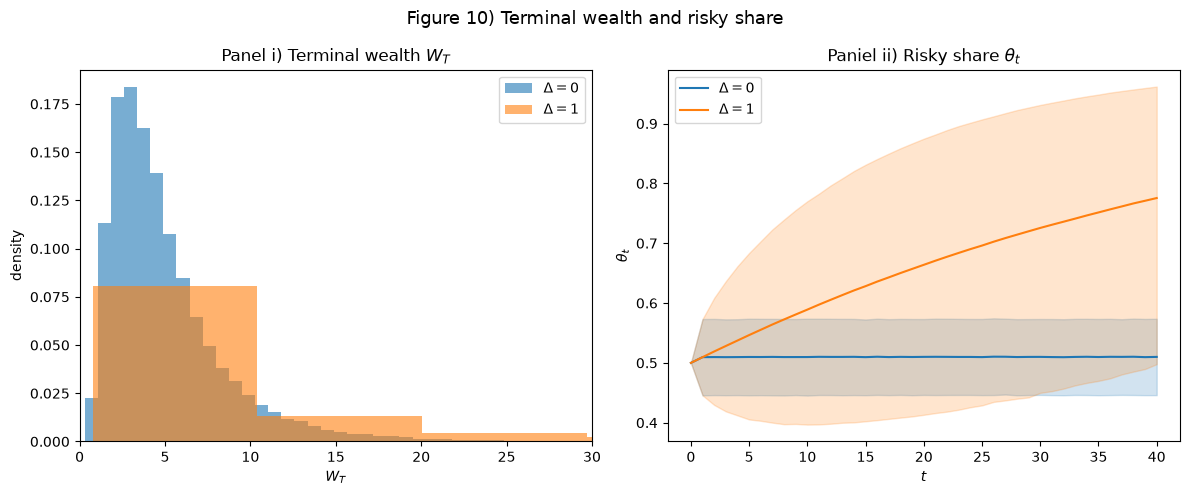

In [114]:
# a. simulating the two rules on the same returns
R = PortfolioModelClass().draw_returns()
m0 = PortfolioModelClass(Delta=0.0,tau=0.0); m0.simulate(R=R)
m1 = PortfolioModelClass(Delta=1.0,tau=0.0); m1.simulate(R=R)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
t = np.arange(m0.par.T+1)

# b. mean with 90% confidendence bands
theta0_mean = m0.sim.theta.mean(axis=0)
theta1_mean = m1.sim.theta.mean(axis=0)
theta0_lo,theta0_hi = np.percentile(m0.sim.theta,[10,90],axis=0)
theta1_lo,theta1_hi = np.percentile(m1.sim.theta,[10,90],axis=0)

# c. plotting the figure
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1.hist(m0.sim.WT,bins=100,density=True,alpha=0.6,color=colors[0],label='$\Delta=0$')
ax1.hist(m1.sim.WT,bins=100,density=True,alpha=0.6,color=colors[1],label='$\Delta=1$')
ax1.set_xlim(0,30)
ax1.set_title('Panel i) Terminal wealth $W_T$')
ax1.set_xlabel('$W_T$'); ax1.set_ylabel('density')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(t,theta0_mean,color=colors[0],label='$\Delta=0$')
ax2.plot(t,theta1_mean,color=colors[1],label='$\Delta=1$')
ax2.fill_between(t,theta0_lo,theta0_hi,color=colors[0],alpha=0.2)
ax2.fill_between(t,theta1_lo,theta1_hi,color=colors[1],alpha=0.2)
ax2.set_title('Paniel ii) Risky share $\\theta_t$')
ax2.set_xlabel('$t$'); ax2.set_ylabel('$\\theta_t$')
ax2.legend(loc='upper left')

fig.suptitle('Figure 10) Terminal wealth and risky share', size=13)
fig.tight_layout()

Under delta equal to zero the mean risky share stays at 0.50 with a thin band, since each period trades it back to target. Under delta = 1 it converges 0.78 with a increasing confidence band.

We see that this raises the mean of the terminal wealth but lowers the 10th percentile and expected utility.  

3.2.4) Never trading the portfolio

When the portfolio is never traded, the mean risky share drifts upwards from 0,50 to t 0,78, and the confidence band increases. This is because the risky asset grows faster on average than the safe asset, so its weight rises when it is never traded. When never trading the risky asset compounds and gets unbalanced

**Question 3.3) different band widths**

3.3.1) values for the different band widths

In [115]:
# a. the same return but across all band widths
R = PortfolioModelClass().draw_returns()

# b. the different band widths
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

# c. simulating the different band widths for the same return and value of tau
rows = []
for d in Deltas:
    m = PortfolioModelClass(Delta=d, tau=0.01)
    m.simulate(R=R)
    s = m.summary()
    rows.append([s.n_trades, s.avg_dist, s.mean_WT, s.median_WT, s.p10_WT, s.EU])

# d. summarizing our results
cols = ['n_trades','avg_dist','mean_WT','median_WT','p10_WT','EU']
table = pd.DataFrame(rows, index=Deltas, columns=cols)
table.index.name = 'Delta'
table.round({'n_trades':2,'avg_dist':4,'mean_WT':3,'median_WT':3,'p10_WT':3,'EU':5})

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,EU
Delta,,,,,,
0.0000,39.0000,0.0394,4.9620,4.0180,1.7680,-0.0699
0.0250,24.5200,0.0400,4.9750,4.0180,1.7690,-0.0697
0.0500,14.3300,0.0429,5.0150,4.0360,1.7670,-0.0695
0.0750,8.7900,0.0480,5.0740,4.0480,1.7650,-0.0693
0.1000,5.8600,0.0541,5.1460,4.0610,1.7590,-0.0695
0.1500,3.1500,0.0680,5.3290,4.1040,1.7350,-0.0699
0.2000,1.9500,0.0835,5.5600,4.1860,1.6790,-0.0709
0.3000,0.9100,0.1180,6.1960,4.3410,1.5360,-0.0734
1.0000,0.0000,0.1911,8.9760,4.4480,1.4850,-0.0767


3.3.2) Plotting

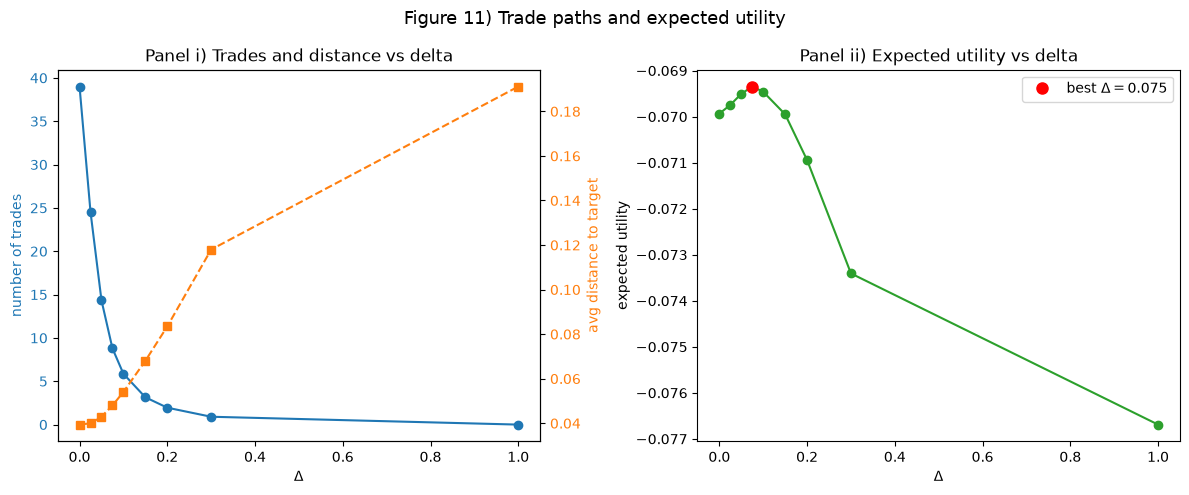

In [116]:
# a. setting the colors
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
D = np.array(Deltas)

fig = plt.figure(figsize=(12,5))

# b. Panel i) number of trades and average distance vs Delta (two y-axes)
ax1 = fig.add_subplot(1,2,1)
ax1.plot(D, table['n_trades'], 'o-', color=colors[0], label='number of trades')
ax1.set_xlabel('$\\Delta$'); ax1.set_ylabel('number of trades', color=colors[0])
ax1.tick_params(axis='y', labelcolor=colors[0])

ax1b = ax1.twinx()                     # second y-axis for the distance (different scale)
ax1b.grid(False)
ax1b.plot(D, table['avg_dist'], 's--', color=colors[1], label='avg distance')
ax1b.set_ylabel('avg distance to target', color=colors[1])
ax1b.tick_params(axis='y', labelcolor=colors[1])
ax1.set_title('Panel i) Trades and distance vs delta')

# b. panel 2: expected utility vs Delta, best rule marked
ax2 = fig.add_subplot(1,2,2)
ax2.plot(D, table['EU'], 'o-', color=colors[2])
dbest = table['EU'].idxmax()
ax2.plot(dbest, table['EU'].max(), '.', color='red', markersize=16, label=f'best $\\Delta={dbest}$')
ax2.set_xlabel('$\\Delta$'); ax2.set_ylabel('expected utility')
ax2.set_title('Panel ii) Expected utility vs delta'); ax2.legend()

fig.suptitle('Figure 11) Trade paths and expected utility', size=13)
fig.tight_layout()

3.3.3) Improvement in utility

In [117]:
# a. best rule by expected utility
dbest = table['EU'].idxmax()
EU_best = table['EU'].max()

# b. improvement over delta = 0 and delta = 1
print(f'The optimal delta = {dbest} with corresponding uitlity of {EU_best:.4f}')
print(f'The optimal beats delta=0 by {EU_best - table.loc[0,"EU"]:.4f}')
print(f'The optimal betas delta=1 by {EU_best - table.loc[1,"EU"]:.4f}')

The optimal delta = 0.075 with corresponding uitlity of -0.0693
The optimal beats delta=0 by 0.0006
The optimal betas delta=1 by 0.0073


Panel i)  shows the trade-off, that as delta grows, the number of trades decreased from 39 to 0, while the average distance to the target increases from 0.04 to 0.19. A larger confidence band saves trading costs but lets the risky share drift further.

Panel ii) shows that expected utility peaks at delta = 0,075 with a utility of −0,0693. It beats delta=0 by only 0,0006 and delta=1 by 0,0073. So trading every period is almost as good as the best rule, since the cost tau=0,01 is small, while never trading is clearly worse because the drift is not corrected.

3.3.4) description

As delta grows the number of trades falls and the risky share drifts further away from the target, so the average distance increases. Going from delta=0 to the best delta=0,075 changes number of trades from 39 to 8,8. The average distance to target, the mean, the median, the 10th percentile and the expected utility does not change alot. Hence the best the best rule leads to almost the same wealth as trading in every period but at a lower trading cost. Thus ranked by the mean of the terminal wealth, we would not pick the same rule
